# Phase 10 — Recommendation Baselines

Three baselines evaluated with leave-last-out at K=10:
1. **Popularity** — global top-N by cumulative interaction score (non-personalised, cold-start proxy)
2. **Content-Based** — item-item cosine similarity on one-hot product attributes + TF-IDF keywords
3. **Collaborative Filtering** — truncated SVD (50 latent factors) on the sparse customer × product interaction matrix

Evaluation metric: **Hit Rate@K** (fraction of users where the held-out product appears in top-K) and **MRR@K** (Mean Reciprocal Rank).

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Config ───────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
K            = 10       # recommendations per customer
N_LATENT     = 50       # SVD latent factors
EVAL_SAMPLE  = 5_000   # customers to evaluate (speed vs. coverage trade-off)

ROOT = Path.cwd().resolve().parent
DATA = ROOT / 'data' / 'processed'
RAW  = ROOT / 'data' / 'raw'
OUT  = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

print(f'K={K} | latent factors={N_LATENT} | eval sample={EVAL_SAMPLE:,} | random_state={RANDOM_STATE}')
print(f'Outputs → {OUT}')

K=10 | latent factors=50 | eval sample=5,000 | random_state=42
Outputs → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
interactions = pd.read_csv(
    DATA / 'mart_recommendation_interactions.csv',
    parse_dates=['first_interaction_date', 'last_interaction_date']
)
products = pd.read_csv(RAW / 'products.csv')
attrs    = pd.read_csv(RAW / 'product_attributes.csv')

prod_meta = products.merge(attrs, on='product_id', how='left')

print(f'Interactions : {len(interactions):>10,} rows')
print(f'Customers    : {interactions.customer_id.nunique():>10,}')
print(f'Products     : {interactions.product_id.nunique():>10,}')
print(f'Avg products per customer: {interactions.groupby("customer_id").product_id.count().mean():.1f}')
print()

# ── Leave-last-out split ──────────────────────────────────────────────────────
# Hold out the single most recent product per customer (by last_interaction_date,
# then highest interaction_score as tie-break) → that is the "ground truth" item
# the recommender should surface.
idx_holdout = (
    interactions
    .sort_values(['customer_id', 'last_interaction_date', 'interaction_score'])
    .groupby('customer_id')
    .tail(1)
    .index
)
test_df  = interactions.loc[idx_holdout].copy()
train_df = interactions.drop(idx_holdout).copy()

# Keep only customers that still have ≥1 train row after removing the holdout
eval_customers = set(train_df.customer_id.unique())
test_df = test_df[test_df.customer_id.isin(eval_customers)]

# Stratified random evaluation sample (reproducible)
rng       = np.random.default_rng(RANDOM_STATE)
eval_ids  = rng.choice(test_df.customer_id.values, size=min(EVAL_SAMPLE, len(test_df)), replace=False)
test_sample = test_df[test_df.customer_id.isin(eval_ids)].set_index('customer_id')['product_id']

# Pre-compute seen-product sets (train) once — reused by all three baselines
seen_by_customer = train_df.groupby('customer_id')['product_id'].apply(set).to_dict()

print(f'Train rows   : {len(train_df):>10,}')
print(f'Test users   : {len(test_df):>10,}')
print(f'Eval sample  : {len(eval_ids):>10,}')
print(f'\nSample holdout items:')
print(test_sample.head())

Interactions :  2,468,038 rows
Customers    :     49,827
Products     :      5,000
Avg products per customer: 49.5

Train rows   :  2,418,211
Test users   :     49,585
Eval sample  :      5,000

Sample holdout items:
customer_id
C000025    P00063
C000027    P04705
C000051    P04827
C000060    P00556
C000070    P03822
Name: product_id, dtype: object


In [3]:
# ── Baseline 1: Popularity ────────────────────────────────────────────────────
# Recommend the globally top-scoring products the customer has not yet seen.
# Non-personalised; strong cold-start benchmark.
t0 = time.time()

global_pop = (
    train_df.groupby('product_id')['interaction_score']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'interaction_score': 'pop_score'})
)
# Use a buffer 10× K so we never run out after filtering seen items
global_top = global_pop['product_id'].head(K * 10).tolist()

hits_pop = 0
mrr_pop  = 0.0
for cust_id, held_product in test_sample.items():
    seen = seen_by_customer.get(cust_id, set())
    recs = [p for p in global_top if p not in seen][:K]
    if held_product in recs:
        hits_pop += 1
        mrr_pop  += 1.0 / (recs.index(held_product) + 1)

hit_rate_pop = hits_pop / len(test_sample)
mrr_pop     /= len(test_sample)

print(f'Popularity baseline  [{time.time()-t0:.1f}s]')
print(f'  Hit Rate@{K}: {hit_rate_pop:.4f}')
print(f'  MRR@{K}:      {mrr_pop:.4f}')
print(f'\nTop 10 globally popular products:')
print(global_pop.head(10).to_string(index=False))

Popularity baseline  [0.2s]
  Hit Rate@10: 0.0036
  MRR@10:      0.0016

Top 10 globally popular products:
product_id  pop_score
    P02564     4616.5
    P01779     3970.5
    P04109     3856.5
    P03986     3842.0
    P04887     3267.0
    P01800     3175.5
    P03758     2934.0
    P02382     2900.5
    P03360     2880.0
    P04392     2840.0


In [4]:
# ── Baseline 2: Content-Based Filtering ──────────────────────────────────────
# Build a product feature vector per item, compute item-item cosine similarity.
# For each user: aggregate similarity vectors across seen products (mean),
# mask out already-seen items, return top-K by score.
#
# Features used:
#   • One-hot: category, subcategory, price_tier, brand_type, margin_band,
#              color, size_group, material_type, recommendation_embedding_group
#   • Boolean: eco_flag, bundle_candidate_flag, seasonal_flag, premium_flag
#   • TF-IDF (50 terms): description_keywords
t0 = time.time()

# ── Product feature matrix ────────────────────────────────────────────────────
cat_cols = [
    'category', 'subcategory', 'price_tier', 'brand_type', 'margin_band',
    'color', 'size_group', 'material_type', 'recommendation_embedding_group'
]
cat_dummies = pd.get_dummies(
    prod_meta.set_index('product_id')[cat_cols],
    columns=cat_cols
).astype(np.float32)

bool_cols = ['eco_flag', 'bundle_candidate_flag', 'seasonal_flag', 'premium_flag']
bool_feats = prod_meta.set_index('product_id')[bool_cols].astype(np.float32)

tfidf  = TfidfVectorizer(max_features=50, token_pattern=r'[a-zA-Z_]+')
kw_mat = tfidf.fit_transform(prod_meta['description_keywords'].fillna(''))
kw_df  = pd.DataFrame(
    kw_mat.toarray(),
    index=prod_meta['product_id'],
    columns=[f'kw_{w}' for w in tfidf.get_feature_names_out()]
).astype(np.float32)

feat_df     = cat_dummies.join(bool_feats).join(kw_df)
feat_matrix = normalize(feat_df.values, norm='l2')
prod_list   = feat_df.index.tolist()
prod_idx    = {pid: i for i, pid in enumerate(prod_list)}

print(f'Product feature matrix: {feat_matrix.shape}  [{time.time()-t0:.1f}s]')

# ── Item-item cosine similarity (5000×5000, ~100 MB) ─────────────────────────
t1 = time.time()
sim_matrix = cosine_similarity(feat_matrix)   # (5000, 5000)
print(f'Similarity matrix: {sim_matrix.shape}  [{time.time()-t1:.1f}s]')

# ── Evaluate ──────────────────────────────────────────────────────────────────
hits_cb = 0
mrr_cb  = 0.0

for cust_id, held_product in test_sample.items():
    if held_product not in prod_idx:
        continue
    s_idx = np.array([prod_idx[p] for p in seen_by_customer.get(cust_id, set()) if p in prod_idx])
    if len(s_idx) == 0:
        continue

    # Mean similarity vector across the customer's seen products; mask seen items
    agg = sim_matrix[s_idx].mean(axis=0).copy()   # (5000,)
    agg[s_idx] = -np.inf

    # Top-K by partial sort
    top_k_idx = np.argpartition(agg, -K)[-K:]
    top_k_idx = top_k_idx[np.argsort(agg[top_k_idx])[::-1]]

    h_idx = prod_idx[held_product]
    if h_idx in top_k_idx:
        hits_cb += 1
        rank     = int(np.where(top_k_idx == h_idx)[0][0]) + 1
        mrr_cb  += 1.0 / rank

hit_rate_cb = hits_cb / len(test_sample)
mrr_cb     /= len(test_sample)

print(f'\nContent-Based  [{time.time()-t0:.1f}s]')
print(f'  Hit Rate@{K}: {hit_rate_cb:.4f}')
print(f'  MRR@{K}:      {mrr_cb:.4f}')

Product feature matrix: (5000, 750)  [0.1s]
Similarity matrix: (5000, 5000)  [0.2s]

Content-Based  [2.9s]
  Hit Rate@10: 0.0062
  MRR@10:      0.0022


In [5]:
# ── Baseline 3: Collaborative Filtering (Truncated SVD) ──────────────────────
# Decompose the sparse customer × product interaction matrix using SVD.
# R ≈ U Σ Vᵀ  →  R̂ = U Σ Vᵀ gives predicted scores for unseen items.
# Items already interacted with are masked before ranking.
t0 = time.time()

# ── Build sparse matrix ───────────────────────────────────────────────────────
all_customers   = sorted(train_df.customer_id.unique())
all_products_cf = sorted(train_df.product_id.unique())
cust_to_idx_cf  = {c: i for i, c in enumerate(all_customers)}
prod_to_idx_cf  = {p: i for i, p in enumerate(all_products_cf)}

row_idx = train_df.customer_id.map(cust_to_idx_cf).values
col_idx = train_df.product_id.map(prod_to_idx_cf).values
values  = train_df.interaction_score.values.astype(np.float32)

R = csr_matrix((values, (row_idx, col_idx)),
               shape=(len(all_customers), len(all_products_cf)))

density = R.nnz / (R.shape[0] * R.shape[1]) * 100
print(f'Sparse matrix : {R.shape}  nnz={R.nnz:,}  density={density:.3f}%  [{time.time()-t0:.1f}s]')

# ── Truncated SVD ─────────────────────────────────────────────────────────────
t1 = time.time()
U, sigma, Vt = svds(R.astype(np.float64), k=N_LATENT)
order = np.argsort(-sigma)
U, sigma, Vt = U[:, order], sigma[order], Vt[order, :]
print(f'SVD : U{U.shape} Σ{sigma.shape} Vt{Vt.shape}  [{time.time()-t1:.1f}s]')
print(f'Top-5 singular values: {sigma[:5].round(1)}')

# ── Reconstruct scores for eval customers only ────────────────────────────────
eval_cust_cf  = [c for c in eval_ids if c in cust_to_idx_cf]
eval_row_idx  = np.array([cust_to_idx_cf[c] for c in eval_cust_cf])
U_eval        = U[eval_row_idx]                   # (n_eval, N_LATENT)
R_hat_eval    = (U_eval * sigma) @ Vt             # (n_eval, n_products)

# Mask training interactions so the model can't trivially re-recommend seen items
R_train_eval                        = np.asarray(R[eval_row_idx].todense())
R_hat_eval_masked                   = R_hat_eval.copy()
R_hat_eval_masked[R_train_eval > 0] = -np.inf

# ── Evaluate ──────────────────────────────────────────────────────────────────
held_map = {c: test_sample.get(c) for c in eval_cust_cf if test_sample.get(c) is not None}

hits_svd = 0
mrr_svd  = 0.0
for i, cust in enumerate(eval_cust_cf):
    held = held_map.get(cust)
    if held is None or held not in prod_to_idx_cf:
        continue
    h_idx  = prod_to_idx_cf[held]
    scores = R_hat_eval_masked[i]

    top_k_idx = np.argpartition(scores, -K)[-K:]
    top_k_idx = top_k_idx[np.argsort(scores[top_k_idx])[::-1]]

    if h_idx in top_k_idx:
        hits_svd += 1
        rank      = int(np.where(top_k_idx == h_idx)[0][0]) + 1
        mrr_svd  += 1.0 / rank

n_eval_cf    = len(eval_cust_cf)
hit_rate_svd = hits_svd / n_eval_cf
mrr_svd     /= n_eval_cf

print(f'\nCollaborative Filtering (SVD-{N_LATENT})  [{time.time()-t0:.1f}s]')
print(f'  Eval users  : {n_eval_cf:,}')
print(f'  Hit Rate@{K} : {hit_rate_svd:.4f}')
print(f'  MRR@{K}      : {mrr_svd:.4f}')

Sparse matrix : (49585, 5000)  nnz=2,418,211  density=0.975%  [0.7s]
SVD : U(49585, 50) Σ(50,) Vt(50, 5000)  [2.2s]
Top-5 singular values: [588.5 330.7 280.6 226.5 223.2]

Collaborative Filtering (SVD-50)  [3.2s]
  Eval users  : 5,000
  Hit Rate@10 : 0.0104
  MRR@10      : 0.0035


=== Recommendation Baselines — Evaluation Summary (K=10) ===
                method  hit_rate_at_k  mrr_at_k  k
   Popularity (global)         0.0036    0.0016 10
Content-Based (cosine)         0.0062    0.0022 10
Collab Filter (SVD-50)         0.0104    0.0035 10


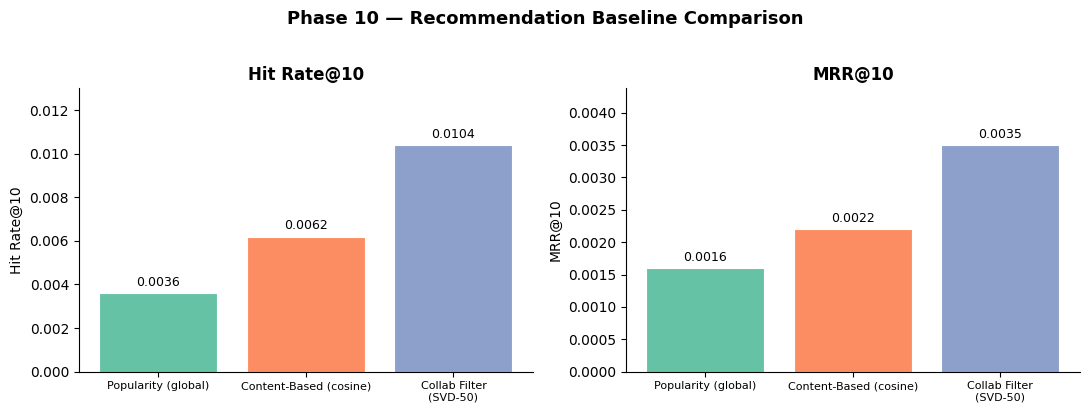

Chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase10_recommendation_eval.png
Metrics saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase10_recommendation_eval.csv
Popularity ranking saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase10_global_popularity_ranking.csv


In [6]:
# ── Comparison & Export ───────────────────────────────────────────────────────
results = pd.DataFrame([
    {'method': 'Popularity (global)',             'hit_rate_at_k': hit_rate_pop, 'mrr_at_k': mrr_pop,  'k': K},
    {'method': 'Content-Based (cosine)',          'hit_rate_at_k': hit_rate_cb,  'mrr_at_k': mrr_cb,   'k': K},
    {'method': f'Collab Filter (SVD-{N_LATENT})', 'hit_rate_at_k': hit_rate_svd, 'mrr_at_k': mrr_svd,  'k': K},
])
results['hit_rate_at_k'] = results['hit_rate_at_k'].round(4)
results['mrr_at_k']      = results['mrr_at_k'].round(4)

print(f'=== Recommendation Baselines — Evaluation Summary (K={K}) ===')
print(results.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = sns.color_palette('Set2', 3)
methods = results['method'].str.replace(f' \\(SVD-{N_LATENT}\\)', f'\n(SVD-{N_LATENT})', regex=True)

for ax, metric, label in zip(
    axes,
    ['hit_rate_at_k', 'mrr_at_k'],
    [f'Hit Rate@{K}', f'MRR@{K}']
):
    bars = ax.bar(methods, results[metric], color=palette, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0, results[metric].max() * 1.25)
    ax.tick_params(axis='x', labelsize=8)
    sns.despine(ax=ax)

fig.suptitle('Phase 10 — Recommendation Baseline Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = OUT / 'phase10_recommendation_eval.png'
fig.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {chart_path}')

# ── Save metrics CSV ──────────────────────────────────────────────────────────
csv_path = OUT / 'phase10_recommendation_eval.csv'
results.to_csv(csv_path, index=False)
print(f'Metrics saved → {csv_path}')

# ── Save popular products catalogue ──────────────────────────────────────────
pop_path = OUT / 'phase10_global_popularity_ranking.csv'
global_pop.to_csv(pop_path, index=False)
print(f'Popularity ranking saved → {pop_path}')